# Part 1: Freshness Classification Using Deep Learning

## Step 1: Data Preprocessing

In [1]:
# --Library Imports--

# File and directory management
import os
import shutil
import random

# Data handling and visualization
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import drive
import hashlib

# Deep Learning framework and utilities
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

# Pre-trained models and specialized preprocessing
from tensorflow.keras.applications import  EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess

from sklearn.metrics import classification_report, confusion_matrix

# Kaggle dataset downloader
import kagglehub

# --Environment Setup--

# Mount Google Drive for saving results
drive.mount('/content/drive')

# Set global seeds for reproducible results
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


Mounted at /content/drive


In [2]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("muhriddinmuxiddinov/fruits-and-vegetables-dataset")

print("Dataset path:", path)

Using Colab cache for faster access to the 'fruits-and-vegetables-dataset' dataset.
Dataset path: /kaggle/input/fruits-and-vegetables-dataset


In [3]:
# Show dataset contents
print(os.listdir(path))

['Fruits_Vegetables_Dataset(12000)']


In [4]:
# Set base path
base_path = os.path.join(path, 'Fruits_Vegetables_Dataset(12000)')
print(os.listdir(base_path))

['Vegetables', 'Fruits']


In [5]:
# Show classes inside Fruits and Vegetables
print("Fruits:", os.listdir(os.path.join(base_path, 'Fruits')))
print("Vegetables:", os.listdir(os.path.join(base_path, 'Vegetables')))

Fruits: ['RottenBanana', 'FreshMango', 'FreshBanana', 'FreshStrawberry', 'RottenApple', 'RottenStrawberry', 'FreshOrange', 'RottenOrange', 'RottenMango', 'FreshApple']
Vegetables: ['FreshPotato', 'RottenTomato', 'RottenBellpepper', 'FreshBellpepper', 'FreshCucumber', 'FreshTomato', 'RottenCarrot', 'RottenCucumber', 'RottenPotato', 'FreshCarrot']


In [6]:
# Merge all classes into one folder
data_path = '/content/data/all_classes'
os.makedirs(data_path, exist_ok=True)

for group in ['Fruits', 'Vegetables']:
    group_path = os.path.join(base_path, group)

    for cls in os.listdir(group_path):
        src = os.path.join(group_path, cls)
        dst = os.path.join(data_path, cls)

        if os.path.isdir(src):
            shutil.copytree(src, dst, dirs_exist_ok=True)



In [7]:
# Show class names and count them
classes = os.listdir(data_path)

print("Classes:", classes)
print("Total number of classes:", len(classes))

Classes: ['FreshCucumber', 'RottenBellpepper', 'FreshMango', 'RottenCarrot', 'FreshApple', 'RottenApple', 'RottenTomato', 'FreshBanana', 'FreshStrawberry', 'RottenStrawberry', 'FreshOrange', 'FreshTomato', 'FreshCarrot', 'FreshPotato', 'RottenMango', 'RottenOrange', 'RottenCucumber', 'RottenPotato', 'RottenBanana', 'FreshBellpepper']
Total number of classes: 20


In [8]:
# Count images in each class
for cls in classes:
    class_path = os.path.join(data_path, cls)

    if os.path.isdir(class_path):
        print(f"{cls}: {len(os.listdir(class_path))}")

FreshCucumber: 608
RottenBellpepper: 591
FreshMango: 605
RottenCarrot: 580
FreshApple: 612
RottenApple: 588
RottenTomato: 596
FreshBanana: 624
FreshStrawberry: 603
RottenStrawberry: 596
FreshOrange: 609
FreshTomato: 604
FreshCarrot: 620
FreshPotato: 615
RottenMango: 593
RottenOrange: 591
RottenCucumber: 593
RottenPotato: 585
RottenBanana: 576
FreshBellpepper: 611


In [9]:
# Generate an MD5 hash for an image file
def get_image_hash(img_path):
    with open(img_path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

# Check for duplicate images
all_hashes = {}
duplicates = []

for cls in classes:
    class_path = os.path.join(data_path, cls)

    for file in os.listdir(class_path):
        img_path = os.path.join(class_path, file)
        img_hash = get_image_hash(img_path)

        if img_hash in all_hashes:
            duplicates.append((img_path, all_hashes[img_hash]))
        else:
            all_hashes[img_hash] = img_path

# Display results
print(f"Number of duplicate images: {len(duplicates)}")

for dup in duplicates[:10]:  # Show first 10 duplicates
    print(dup)

Number of duplicate images: 232
('/content/data/all_classes/FreshCucumber/freshCucumber (489).jpg', '/content/data/all_classes/FreshCucumber/freshCucumber (457).jpg')
('/content/data/all_classes/FreshCucumber/freshCucumber (212).jpg', '/content/data/all_classes/FreshCucumber/freshCucumber (284).jpg')
('/content/data/all_classes/FreshCucumber/freshCucumber (214).jpg', '/content/data/all_classes/FreshCucumber/freshCucumber (286).jpg')
('/content/data/all_classes/FreshCucumber/freshCucumber (519).jpg', '/content/data/all_classes/FreshCucumber/freshCucumber (467).jpg')
('/content/data/all_classes/FreshCucumber/freshCucumber (211).jpg', '/content/data/all_classes/FreshCucumber/freshCucumber (283).jpg')
('/content/data/all_classes/FreshCucumber/freshCucumber (506).jpg', '/content/data/all_classes/FreshCucumber/freshCucumber (459).jpg')
('/content/data/all_classes/FreshCucumber/freshCucumber (291).jpg', '/content/data/all_classes/FreshCucumber/freshCucumber (290).jpg')
('/content/data/all_cla

In [10]:
# Remove duplicate images
removed = 0
seen_hashes = {}

for cls in sorted(classes):
    class_path = os.path.join(data_path, cls)

    for file in sorted(os.listdir(class_path)):
        img_path = os.path.join(class_path, file)
        img_hash = get_image_hash(img_path)

        if img_hash in seen_hashes:
            os.remove(img_path)
            removed += 1
        else:
            seen_hashes[img_hash] = img_path

print(f"Removed {removed} duplicate images")

# Update classes and display image counts
classes = os.listdir(data_path)

for cls in sorted(classes):
    class_path = os.path.join(data_path, cls)
    print(f"{cls}: {len(os.listdir(class_path))}")

Removed 232 duplicate images
FreshApple: 606
FreshBanana: 623
FreshBellpepper: 600
FreshCarrot: 610
FreshCucumber: 591
FreshMango: 605
FreshOrange: 609
FreshPotato: 610
FreshStrawberry: 603
FreshTomato: 602
RottenApple: 586
RottenBanana: 576
RottenBellpepper: 547
RottenCarrot: 506
RottenCucumber: 576
RottenMango: 593
RottenOrange: 591
RottenPotato: 564
RottenStrawberry: 596
RottenTomato: 574


In [11]:
# Check for corrupted images
bad_images = []

for cls in classes:
    class_path = os.path.join(data_path, cls)

    if os.path.isdir(class_path):
        for file in os.listdir(class_path):
            img_path = os.path.join(class_path, file)

            try:
                img = Image.open(img_path)
                img.verify()
            except:
                bad_images.append(img_path)

print("Number of bad images:", len(bad_images))

Number of bad images: 0


In [12]:
# Check image color mode
sample_class = os.listdir(data_path)[0]
sample_image = os.listdir(os.path.join(data_path, sample_class))[0]

img_path = os.path.join(data_path, sample_class, sample_image)
img = Image.open(img_path)

print("Image mode:", img.mode)

Image mode: RGB


In [13]:
# Split dataset into train / validation / test
output_path = '/content/data/splitted_data'

train_path = os.path.join(output_path, 'train')
val_path = os.path.join(output_path, 'val')
test_path = os.path.join(output_path, 'test')

for folder in [train_path, val_path, test_path]:
    os.makedirs(folder, exist_ok=True)

random.seed(42)

for cls in sorted(classes):
    class_path = os.path.join(data_path, cls)

    if os.path.isdir(class_path):
        images = sorted(os.listdir(class_path))
        random.shuffle(images)

        total = len(images)
        train_count = int(total * 0.70)
        val_count = int(total * 0.15)

        train_images = images[:train_count]
        val_images = images[train_count:train_count + val_count]
        test_images = images[train_count + val_count:]

        os.makedirs(os.path.join(train_path, cls), exist_ok=True)
        os.makedirs(os.path.join(val_path, cls), exist_ok=True)
        os.makedirs(os.path.join(test_path, cls), exist_ok=True)

        for img in train_images:
            shutil.copy(os.path.join(class_path, img), os.path.join(train_path, cls, img))

        for img in val_images:
            shutil.copy(os.path.join(class_path, img), os.path.join(val_path, cls, img))

        for img in test_images:
            shutil.copy(os.path.join(class_path, img), os.path.join(test_path, cls, img))

In [14]:
# Check for data leakage between train and test sets
train_hashes = set()

for cls in os.listdir(train_path):
    for file in os.listdir(os.path.join(train_path, cls)):
        img_path = os.path.join(train_path, cls, file)
        train_hashes.add(get_image_hash(img_path))

leakage = 0

for cls in os.listdir(test_path):
    for file in os.listdir(os.path.join(test_path, cls)):
        img_path = os.path.join(test_path, cls, file)
        img_hash = get_image_hash(img_path)

        if img_hash in train_hashes:
            leakage += 1

print(f"Number of leaked images from train to test: {leakage}")


Number of leaked images from train to test: 0


In [15]:
# Training data (with augmentation)
train_datagen = ImageDataGenerator(
    preprocessing_function=effnet_preprocess,
    rotation_range=20,       # Rotate images
    zoom_range=0.2,          # Zoom
    width_shift_range=0.1,   # Shift horizontally
    height_shift_range=0.1,  # Shift vertically
    horizontal_flip=True     # Flip images
)

# Validation & test (no augmentation)
val_test_datagen = ImageDataGenerator(
   preprocessing_function=effnet_preprocess,
)


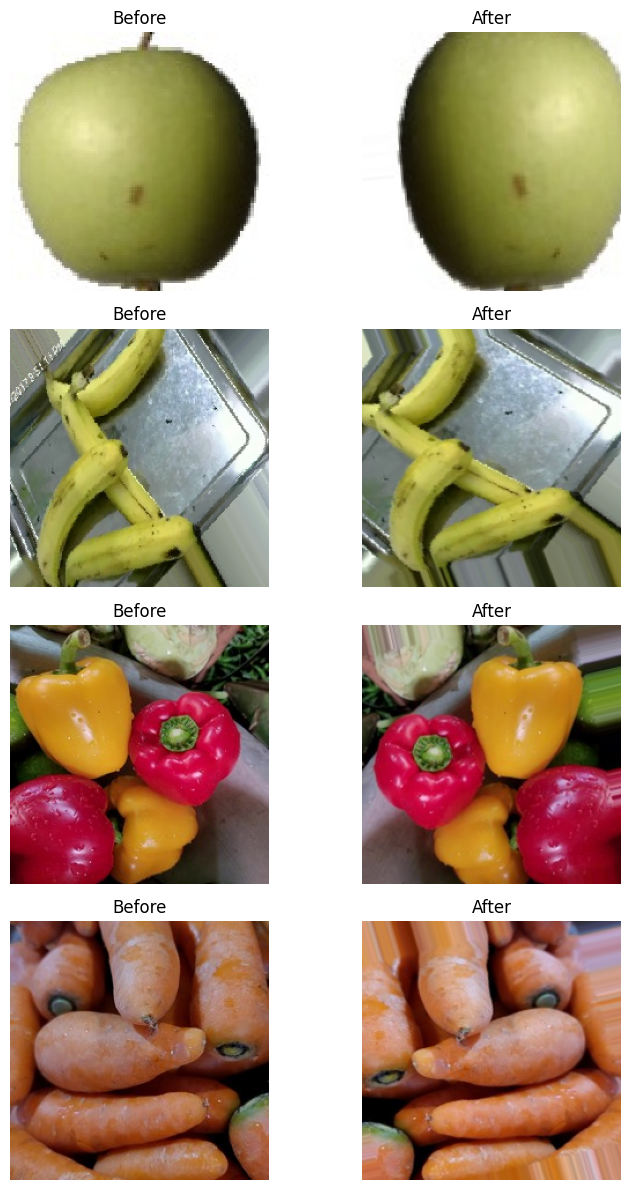

In [16]:
# Show images from different classes
train_path = '/content/data/splitted_data/train'
image_paths = []

# Collect one image from first 4 classes
for cls in sorted(os.listdir(train_path))[:4]:
    class_folder = os.path.join(train_path, cls)
    if os.path.isdir(class_folder):
        img_name = os.listdir(class_folder)[0]
        image_paths.append(os.path.join(class_folder, img_name))

plt.figure(figsize=(8, 12))  # Set figure size

for i, img_path in enumerate(image_paths):
    # Load image and resize to model input size
    img = image.load_img(img_path, target_size=(224, 224))

    # Convert image to array
    img_array = image.img_to_array(img)

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Apply augmentation
    aug_img = next(train_datagen.flow(img_array, batch_size=1))[0]

    # Fix display (normalize values to 0-1)
    aug_img_display = (aug_img - aug_img.min()) / (aug_img.max() - aug_img.min())

    # Show original image
    plt.subplot(4, 2, 2*i + 1)
    plt.imshow(img)
    plt.title("Before")
    plt.axis("off")

    # Show augmented image
    plt.subplot(4, 2, 2*i + 2)
    plt.imshow(aug_img_display)
    plt.title("After")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
# Show class labels
print(len(os.listdir(data_path)))

20


## Step 2: Hyperparameter Tuning - OPTUNA

In [18]:
# Number of output classes
num_classes = len(os.listdir(data_path))
print("Number of classes:", num_classes)

Number of classes: 20


In [ ]:
# Install Optuna (used for automatic hyperparameter tuning)
!pip install optuna -q
import optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.6 MB/s eta 0:00:00


In [ ]:
# Install integration package for advanced callbacks like pruning
!pip install optuna-integration

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 5.2 MB/s eta 0:00:00


In [ ]:
from optuna.integration import KerasPruningCallback

In [19]:
# This function loads images from directory and applies batching
# Batch size is treated as a hyperparameter to be optimized

def create_generators(batch_size):

    # Training generator (with shuffling for better generalization)
    train_gen = train_datagen.flow_from_directory(
        train_path,
        target_size=(224,224),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=True
    )

    # Validation generator (no shuffling for consistent evaluation)
    val_gen = val_test_datagen.flow_from_directory(
        val_path,
        target_size=(224,224),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False
    )

    return train_gen, val_gen

In [20]:
# Defines the architecture using a pre-trained EfficientNetB0 backbone

def build_model(lr, dropout_rate, optimizer_name, weight_decay, dense_units):

    # Load pre-trained EfficientNetB0 without classification head
    base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
    base_model.trainable = False   # Freeze feature extractor

    # Build classification head
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),   # Convert feature maps to vector
        layers.Dense(dense_units, activation='relu'),  # Fully connected layer
        layers.Dropout(dropout_rate),      # Regularization to prevent overfitting
        layers.Dense(num_classes, activation='softmax') # Output layer
    ])

    # Optimizer selection based on hyperparameter tuning
    if optimizer_name == "Adam":
        opt = tf.keras.optimizers.Adam(learning_rate=lr, weight_decay=weight_decay)
    elif optimizer_name == "SGD":
        opt = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9, weight_decay=weight_decay)
    else: #RMSprop
        opt = tf.keras.optimizers.RMSprop(learning_rate=lr, momentum=0.9, weight_decay=weight_decay)

    # Compile model with classification loss
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
# This function is executed for each trial (experiment)
# It defines search space and evaluates model performance

def objective(trial):

    # Define hyperparameter search space
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD", "RMSprop"])
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.5)
    batch_size = trial.suggest_categorical("batch_size", [16, 32])
    dense_units = trial.suggest_categorical("dense_units", [64, 128, 256])

    # Create data loaders for current trial
    train_genO, val_genO = create_generators(batch_size)

    # Build model with sampled hyperparameters
    model = build_model(lr, dropout_rate, optimizer_name, weight_decay, dense_units)

    # Train model for a small number of epochs
    history = model.fit(
        train_genO,
        validation_data=val_genO,
        epochs=10,
        callbacks=[KerasPruningCallback(trial, monitor='val_accuracy')],
        verbose=0
    )

    # Return best validation accuracy achieved in this trial
    return max(history.history['val_accuracy'])



In [ ]:
# RUN OPTUNA STUDY
# Maximizing validation accuracy
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

[I 2026-04-18 08:10:11,966] A new study created in memory with name: no-name-89ccd168-6cf1-4217-a743-1dfb83181e70


Found 8382 images belonging to 20 classes.
Found 1788 images belonging to 20 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
[I 2026-04-18 08:33:39,537] Trial 0 finished with value: 0.9306487441062927 and parameters: {'lr': 0.00010908357655001202, 'optimizer': 'Adam', 'weight_decay': 0.0011075447745551223, 'dropout_rate': 0.3691980600649679, 'batch_size': 32, 'dense_units': 64}. Best is trial 0 with value: 0.9306487441062927.


Found 8382 images belonging to 20 classes.
Found 1788 images belonging to 20 classes.


[I 2026-04-18 08:55:31,469] Trial 1 finished with value: 0.959172248840332 and parameters: {'lr': 0.005387749406510409, 'optimizer': 'SGD', 'weight_decay': 0.0021109255571187505, 'dropout_rate': 0.3704230725651614, 'batch_size': 32, 'dense_units': 256}. Best is trial 1 with value: 0.959172248840332.


...

[I 2026-04-18 10:43:24,020] Trial 7 finished with value: 0.9625279903411865 and parameters: {'lr': 0.0008918229203288363, 'optimizer': 'Adam', 'weight_decay': 0.0002193994552991334, 'dropout_rate': 0.29147635534763167, 'batch_size': 32, 'dense_units': 64}. Best is trial 7 with value: 0.9625279903411865.


Found 8382 images belonging to 20 classes.
Found 1788 images belonging to 20 classes.


[I 2026-04-18 10:46:14,838] Trial 8 pruned. Trial was pruned at epoch 0.


Found 8382 images belonging to 20 classes.
Found 1788 images belonging to 20 classes.


[I 2026-04-18 10:49:03,862] Trial 9 pruned. Trial was pruned at epoch 0.


In [ ]:
# Extract the best parameters
best_p = study.best_params
print(f"Best parameters identified: {best_p}")


Best parameters identified: {'lr': 0.0008918229203288363, 'optimizer': 'Adam', 'weight_decay': 0.0002193994552991334, 'dropout_rate': 0.29147635534763167, 'batch_size': 32, 'dense_units': 64}


In [22]:
# BEST VALUES (FINAL TRAINING SETUP)
# These values are taken from Optuna output and used for final training
lr = 0.0008918229203288363
optimizer = "Adam"
weight_decay = 0.0002193994552991334
dropout_rate = 0.29147635534763167
best_batch = 32
dense_units = 64

## Step 3: Model Training

In [23]:
# Create final data generators using best batch size
train_genf, val_genf = create_generators(best_batch)

Found 8221 images belonging to 20 classes.
Found 1752 images belonging to 20 classes.


In [24]:
# FINAL MODEL TRAINING
# Build final model using best hyperparameters
final_model = build_model(
    lr,
    dropout_rate,
    optimizer,
    weight_decay,
    dense_units
)


# Define callbacks for saving the best model and early stopping
callbacks_list = [
    tf.keras.callbacks.ModelCheckpoint('/content/drive/MyDrive/best_fruit_model.keras', save_best_only=True, monitor='val_accuracy',mode='max', verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, mode='max', min_delta=0.001, restore_best_weights=True)
]

print("Starting final training...")
history = final_model.fit(
    train_genf,
    validation_data=val_genf,
    epochs=15,
    callbacks=callbacks_list
)



16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting final training...
Epoch 1/15
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.5633 - loss: 1.5424

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Epoch 1: val_accuracy improved from None to 0.92523, saving model to /content/drive/MyDrive/best_fruit_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_fruit_model.keras
257/257 ━━━━━━━━━━━━━━━━━━━━ 195s 640ms/step - accuracy: 0.7394 - loss: 0.9260 - val_accuracy: 0.9252 - val_loss: 0.2835
Epoch 2/15
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.8882 - loss: 0.3662
Epoch 2: val_accuracy improved from 0.92523 to 0.95148, saving model to /content/drive/MyDrive/best_fruit_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_fruit_model.keras
257/257 ━━━━━━━━━━━━━━━━━━━━ 129s 503ms/step - accuracy: 0.8953 - loss: 0.3408 - val_accuracy: 0.9515 - val_loss: 0.1916
Epoch 3/15
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.9210 - loss: 0.2531
Epoch 3: val_accuracy did not improve from 0.95148
257/257 ━━━━━━━━━━━━━━━━━━━━ 127s 493ms/step - accuracy: 0.9192 - loss: 0.2528 - val_accuracy: 0.9424 - val_loss: 0.1735
Epoch 4/15
257

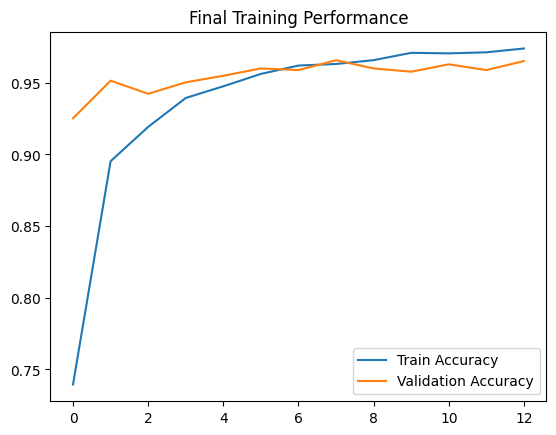

In [25]:
# TRAINING PERFORMANCE VISUALIZATION
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Final Training Performance')
plt.legend()
plt.show()

## Step 4: Model Evaluation

In [26]:

# Load best saved model
model = tf.keras.models.load_model('/content/drive/MyDrive/best_fruit_model.keras')

# Prepare test data
test_gen = val_test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=best_batch,
    class_mode='categorical',
    shuffle=False
)

# Model predictions
y_pred = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

# Class labels
class_names = list(test_gen.class_indices.keys())

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

Found 1781 images belonging to 20 classes.
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 341ms/step
Classification Report:

                  precision    recall  f1-score   support

      FreshApple       0.96      0.99      0.97        92
     FreshBanana       1.00      0.98      0.99        94
 FreshBellpepper       0.97      0.94      0.96        90
     FreshCarrot       0.95      0.98      0.96        92
   FreshCucumber       0.97      0.99      0.98        90
      FreshMango       1.00      0.98      0.99        92
     FreshOrange       0.98      1.00      0.99        92
     FreshPotato       0.95      0.95      0.95        92
 FreshStrawberry       1.00      1.00      1.00        91
     FreshTomato       0.98      0.96      0.97        91
     RottenApple       0.94      0.94      0.94        89
    RottenBanana       0.99      0.99      0.99        86
RottenBellpepper       0.88      0.90      0.89        83
    RottenCarrot       1.00      0.88      0.94        77
  RottenCucumber    

## Step 5: Prediction Visualization

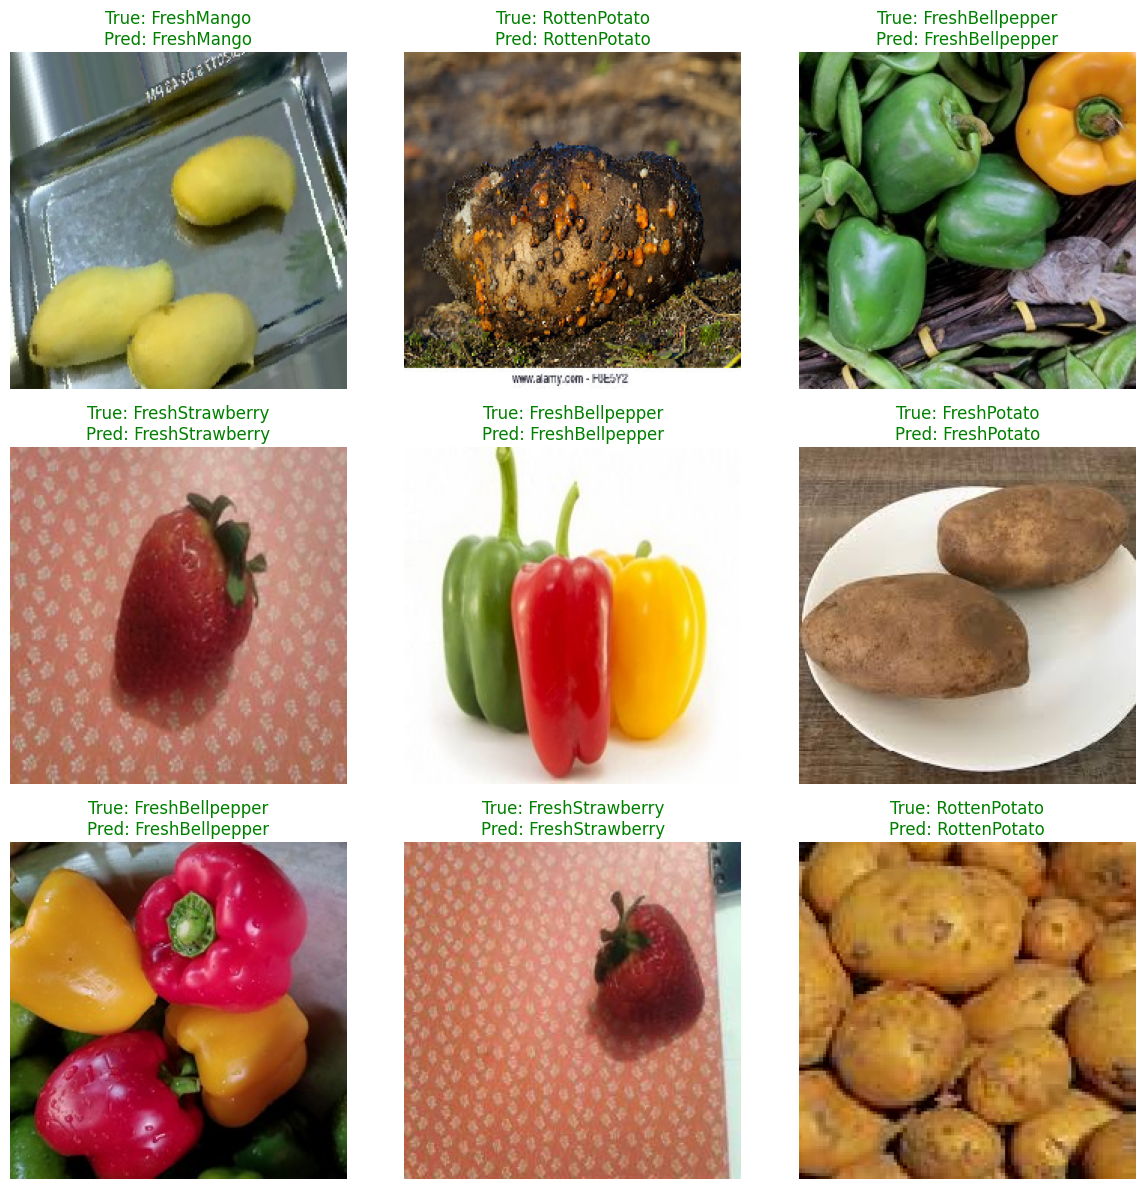

In [27]:
# Number of images to display
num_samples = 9

# Get class names from the test generator
class_names = list(test_gen.class_indices.keys())

# Collect all image paths with their true labels
all_images = []

for cls in class_names:
    class_path = os.path.join(test_path, cls)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        all_images.append((img_path, cls))  # Store (image path, true label)

# Randomly sample images from the entire dataset
sampled_images = random.sample(all_images, num_samples)

# Create a figure to display images
plt.figure(figsize=(12, 12))

for i, (img_path, true_label) in enumerate(sampled_images):
    plt.subplot(3, 3, i + 1)

    # Load image and resize to model input size
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)

    # Add batch dimension (model expects batch input)
    img_array = np.expand_dims(img_array, axis=0)

    # Apply preprocessing (same as training)
    img_array = effnet_preprocess(img_array)

    # Make prediction
    pred = model.predict(img_array, verbose=0)

    # Get predicted class name
    pred_class = class_names[np.argmax(pred)]

    # Set title color: green if correct, red if wrong
    color = "green" if pred_class == true_label else "red"

    # Normalize image for better visualization
    img_display = img_array[0]
    img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())

    # Display image with true and predicted labels
    plt.imshow(img_display)
    plt.title(f"True: {true_label}\nPred: {pred_class}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 6: Explainable AI (Grad-CAM)

In [ ]:
!pip install tf-explain
from tf_explain.core.grad_cam import GradCAM

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.2 MB/s eta 0:00:00


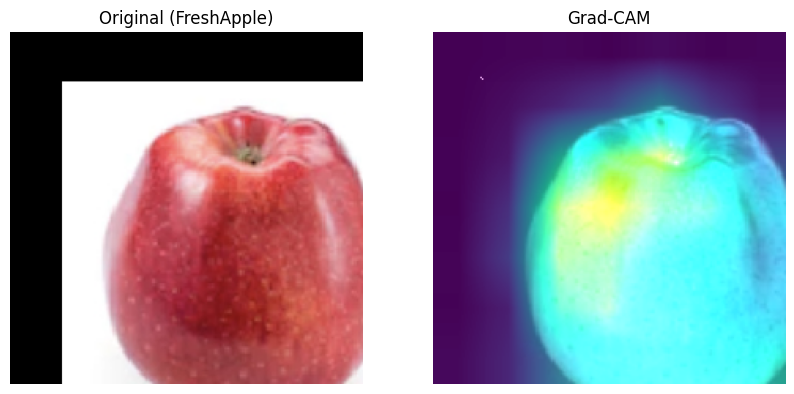

In [ ]:
# Select a random image from the test set
random_sample = random.choice(all_images)
img_path, true_label = random_sample

# Preprocess the image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array_proc = effnet_preprocess(np.expand_dims(img_array, axis=0))

# Initialize GradCAM
explainer = GradCAM()

# Get class index for the true label
class_index = test_gen.class_indices[true_label]

# Create a temporary functional model for tf-explain
backbone = model.layers[0]
inputs = backbone.input
x = backbone.output
for layer in model.layers[1:]:
    x = layer(x)
explainer_model = tf.keras.Model(inputs, x)

# Generate the heatmap
output = explainer.explain(
    validation_data=(img_array_proc, None),
    model=explainer_model,
    class_index=class_index,
    layer_name="top_activation" # The last conv layer in EfficientNetB0 that understands spatial details
)

# Display the results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title(f"Original ({true_label})")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(output)
plt.title("Grad-CAM")
plt.axis('off')

plt.show()